# Root-MUSIC and Spatial Smoothing

In [1]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

In [ ]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen); 
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]); 
  return -1j*2*np.pi/wavelen * a * sensor_pos.T@d_omega; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def calculate_crb(sensor_pos: np.ndarray, N: int, T: int, wl: float, angs_elev: np.ndarray, snr_db: float, S_db: list) -> np.ndarray:
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db)/10 for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 

  Rxx_true = A_mat@R_ss@A_mat.conj().T + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(A_mat.conj().T@A_mat)@A_mat.conj().T; # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = D_mat.conj().T @ P_A_perp @ D_mat; 
  term2 = (R_ss @ A_mat.conj().T @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1*term2); 

  return np.linalg.inv(FIM); 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Benchmark Methods: MVDR, ESPRIT, MUSIC

In [ ]:
def doa_est_capon(theta_scan: np.ndarray, sensor_pos: np.ndarray, R_xx: np.ndarray, wl: float) -> np.ndarray:
  Rxx_inv = np.linalg.inv(R_xx); 
  P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ bartlett) / (hermitian(bartlett) @ Rxx_inv @ bartlett); 
    P_capon[i] = np.squeeze(hermitian(capon) @ R_xx @ capon); 

  return P_capon; 


def doa_est_music(theta_scan: np.ndarray, sensor_pos:  np.ndarray, R_xx: np.ndarray, wl: float, K: int):
  _, e_vec = np.linalg.eigh(R_xx); 
  Un = e_vec[:, :-K]; 

  P_music = np.zeros(len(theta_scan), dtype=np.float64); 

  for i, theta in enumerate(theta_scan):
      a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
      denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
      P_music[i] = 1 / np.squeeze(denominator); 

  return P_music; 


def doa_est_esprit(R_xx: np.ndarray, d: float, wl: float, K: int) -> np.ndarray:
  U, _, _ = np.linalg.svd(R_xx);        # Left singular matrix
  Us = U[:,:K];                         # Signal Subspace

  U1 = Us[:-1,:];                       # First M-1 rows (Subarray 1)
  U2 = Us[1:,:];                        # Last M-1 rows (Subarray 2)
  U12 = np.hstack((U1, U2)); 

  _, _, Vh = np.linalg.svd(U12); 
  Vh = Vh.T.conj(); 
  V12 = Vh[:K, K:]; 
  V22 = Vh[K:, K:]; 

  Psi = -V12 @ np.linalg.inv(V22); 

  eig_vals = np.linalg.eigvals(Psi);    # Complex eigenvalues of the rotation matrix
  phases = np.angle(eig_vals);          # The phases (angles) of the eigenvalues

  estimated_angles_rad = np.arcsin(phases/(2*np.pi*(d/wl))); 
  return np.sort(np.rad2deg(estimated_angles_rad)); # returns in degrees

In [ ]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Narrowband signal frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 1000;       # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90, 90 + ang_res, ang_res);                     # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: 23.203°
Target 1 True Angle: -43.436°


In [5]:
# Data Generation
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 

## Calculating the Cramer-Rao Lower Bound (CRLB)

In [7]:
## Cramer-Rao Bound
CRB_mat = calculate_crb(sensor_pos, N, T, true_angles, snr_db, S_db, wl); 
CRB_var = np.diag(CRB_mat);       # The diagonal elements are the minimum variances for target 1 and target 2
CRB_rmse = np.sqrt(CRB_var);      # Convert variance (deg^2) to Standard Deviation / RMSE (deg)

## Benchmark Algorithms

In [8]:
# Running the compared algorithms (DAS, MVDR, and MUSIC)
Rxx_samp = (X @ X.conj().T)/T; 
_, eigenvectors = np.linalg.eigh(Rxx_samp); 
Un = eigenvectors[:, :-K];            # Noise space

P_bartlett = doa_est_bartlett(theta_scan, sensor_pos, Rxx_samp, wl); 
P_bartlett_dB = 10*np.log10(np.abs(np.multiply(P_bartlett/np.amax(P_bartlett), np.conjugate(P_bartlett/np.amax(P_bartlett))))); 

P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 

P_music = doa_est_music(theta_scan, sensor_pos, Rxx_samp, wl, K); 
P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 

## The Root-MUSIC Algorithm


In [ ]:
# The Root-MUSIC algorithm
C = Un @ Un.conj().T; 

# The polynomial coefficients. np.roots expects coefficients in descending order of powers: z^(2N-2) down to z^0.
coeffs = np.zeros(2 * N - 1, dtype=complex); 
for i, k in enumerate(range(N - 1, -N, -1)):
  coeffs[i] = np.sum(np.diag(C, k)); 

roots = np.roots(coeffs); # The roots of the polynomial coefficients
inside_roots = roots[np.abs(roots) < 1.0]; # The roots inside the unit circle (|z| < 1)
inside_roots_sorted = inside_roots[np.argsort(np.abs(inside_roots))[::-1]]; 
inside_roots_selected = inside_roots_sorted[:K]; 

# Extracting phases and calculating the corresponding angles
phases = np.angle(inside_roots_selected); 
sin_theta = (phases * wl) / (2 * np.pi * d);  # Phase = 2 * pi * d / wl * sin(theta)

# Clip values to handle occasional minor numerical precision edge cases outside [-1, 1]
sin_theta = np.clip(sin_theta, -1.0, 1.0); 

# Convert to degrees and sort
est_angles = np.sort(np.rad2deg(np.arcsin(sin_theta))); 

In [10]:
# Print and compare the results
print("="*45); 
print(f"{'Target':<8} | {'True Angle':<12} | {'Root-MUSIC Estimate':<20}"); 
print("="*45); 
sorted_true = np.sort(true_angles); 
for i in range(K):
    print(f"Target {i+1} | {sorted_true[i]:.2f}°{"":<7} | {est_angles[i]:.2f}°"); 
print("="*45); 

Target   | True Angle   | Root-MUSIC Estimate 
Target 1 | -43.44°        | -43.44°
Target 2 | 23.20°        | 23.23°


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


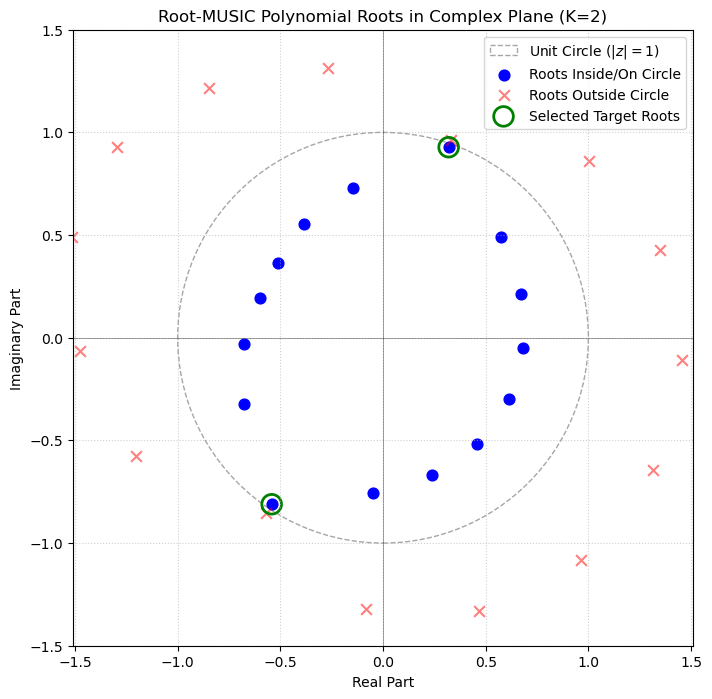

In [ ]:
# Create the complex plane plot
plt.figure(figsize=(8, 8)); 

# Plot the ideal Unit Circle boundary
unit_circle = plt.Circle((0,0), 1.0, color='gray', fill=False, linestyle='--', alpha=0.7, label='Unit Circle ($|z|=1$)'); 
plt.gca().add_patch(unit_circle); 

# Separate roots inside and outside for visual distinction
inside_idx = np.abs(roots) <= 1.0; 
outside_idx = np.abs(roots) > 1.0; 

plt.scatter(roots[inside_idx].real, roots[inside_idx].imag,
            color='blue', marker='o', s=60, label='Roots Inside/On Circle'); 
plt.scatter(roots[outside_idx].real, roots[outside_idx].imag,
            color='red', marker='x', s=60, alpha=0.5, label='Roots Outside Circle'); 

# Highlight the chosen target roots (the K roots inside closest to the circle boundary)
inside_roots = roots[inside_idx]; 
selected_idx = np.argsort(np.abs(inside_roots))[::-1][:K]; 
plt.scatter(inside_roots[selected_idx].real, inside_roots[selected_idx].imag,
            facecolors='none', edgecolors='green', marker='o', s=200, linewidths=2, label='Selected Target Roots'); 

# Formatting the plot
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5); 
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5); 
plt.title(f'Root-MUSIC Polynomial Roots in Complex Plane (K={K})'); 
plt.xlabel('Real Part'); 
plt.ylabel('Imaginary Part'); 
plt.grid(True, linestyle=':', alpha=0.6); 
plt.axis('equal'); 
plt.xlim([-1.5, 1.5]); 
plt.ylim([-1.5, 1.5]); 
plt.legend(loc='upper right'); 
plt.show(); 

In [ ]:
def doa_est_root_music(R_xx: np.ndarray, wl: float, K: int):
  _, e_vec = np.linalg.eigh(R_xx); 
  Un = e_vec[:, :-K]; 
  C = Un @ Un.conj().T; 

  coeffs = np.zeros(2 * N - 1, dtype=complex); # The polynomial coefficients
  for i, k in enumerate(range(N - 1, -N, -1)):
    coeffs[i] = np.sum(np.diag(C, k)); 
  
  roots = np.roots(coeffs); # The roots of the polynomial coefficients
  root_i = roots[np.abs(roots) < 1.0]; # The roots inside the unit circle (|z| < 1)
  root_i_sort = root_i[np.argsort(np.abs(root_i))[::-1]]; 
  root_i_sel = root_i_sort[:K]; 

  # Extracting phases and calculating the corresponding angles
  phases = np.angle(root_i_sel); 
  sin_theta = (phases * wl) / (2 * np.pi * d); 

  # Clip values to handle occasional minor numerical precision edge cases outside [-1, 1]
  sin_theta = np.clip(sin_theta, -1.0, 1.0); 

  # Convert to degrees and sort
  est_angles = np.sort(np.rad2deg(np.arcsin(sin_theta))); 

  return est_angles; 
